# Régression du prix — la-centrale-fr

Repère : **régression linéaire** (`LinearRegression`) enrichie marque + modèle.
Cible = `price`. Périmètre produit : prix ≤ `SEUIL_PRIX` (réglable).

**Métriques** (toutes = « à quel point on se trompe ») :
- **MAE** = erreur moyenne en euros (intuitive).
- **RMSE** = erreur en euros, **punit fort les gros ratés**.
- **R²** = part de variance expliquée (1 = parfait, 0 = aussi bon que la moyenne).

> Préprocessing = étage d'un `Pipeline` sklearn, **fit sur le train seul** (pas de fuite).
> Le regroupement des carburants rares est piloté par l'**hyperparamètre** `min_frequency` du OneHot, tuné par validation croisée.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RAW = Path("../../data/la-centrale-fr/raw/la_centrale.csv")
SEUIL_PRIX = 50_000  # périmètre produit (vendeur particulier) — réglable
df = pd.read_csv(RAW)
print(f"brut : {df.shape[0]} lignes x {df.shape[1]} colonnes")

brut : 141199 lignes x 30 colonnes


## 1. Préprocessing léger (le brut est déjà typé)

- drop `Unnamed: 0` (index par défaut) et `dep_name` (redondant avec `dep`) ;
- dérive `age` en années depuis `circuilation_date` (réf. mars 2024, juste après la dernière annonce) ;
- garde-fous : `price` > 0 ; périmètre `price` ≤ `SEUIL_PRIX`.
Le fichier `raw/` n'est jamais modifié.

In [2]:
REF_DATE = pd.Timestamp("2024-03-01")  # dernière annonce ~fév. 2024
circ = pd.to_datetime(df["circuilation_date"], errors="coerce")
df["age"] = (REF_DATE - circ).dt.days / 365.25

df = df.drop(columns=["Unnamed: 0", "dep_name"])
df = df[df["price"] > 0]
df = df[df["price"] <= SEUIL_PRIX]

PROC = Path("../../data/la-centrale-fr/processed")
PROC.mkdir(parents=True, exist_ok=True)
df.to_csv(PROC / "cars_clean.csv", index=False)
print(f"après périmètre <= {SEUIL_PRIX} EUR : {df.shape[0]} lignes")

après périmètre <= 50000 EUR : 124315 lignes


## 2. Features (X), cible (y), split train/test

- numériques : `age`, `km`, `HorseP`, `doors_nb`, `numbe_seats`, `first_hand`, `Gearbox_auto`
- **carburant** : `fuel` (8) → OneHot, regroupement des rares piloté par `min_frequency`
- **marque** : `model1` (65) → OneHot
- **modèle** : `model2` (1172) → OneHot **complet** (une colonne par modèle vu au train)

Split **80 % / 20 %**, `random_state=42`.

In [3]:
num_features   = ["age", "km", "HorseP", "doors_nb", "numbe_seats", "first_hand", "Gearbox_auto"]
fuel_feature   = ["fuel"]
brand_feature  = ["model1"]
model_feature  = ["model2"]

X = df[num_features + fuel_feature + brand_feature + model_feature]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])
print("model2 distincts (train):", X_train["model2"].nunique())

train: 99452 | test: 24863
model2 distincts (train): 924


## 3. Pipeline : préprocessing + modèle

`ColumnTransformer`, tout **fit sur le train seul** :
- numériques : médiane + standardisation ;
- `fuel` : OneHot `min_frequency=FUEL_MIN_FREQ` (regroupe les rares) ;
- `model1` : OneHot complet ;
- `model2` : OneHot complet (aucun regroupement).
`handle_unknown="ignore"` partout → modalité absente du train = vecteur zéro, pas de crash.

In [4]:
FUEL_MIN_FREQ = 1  # 1 = garde les 8 carburants ; plus haut = regroupe les rares

def build_prep(fuel_min_freq=1):
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), num_features),
        ("fuel",  OneHotEncoder(handle_unknown="ignore", min_frequency=fuel_min_freq,
                                sparse_output=False), fuel_feature),
        ("brand", OneHotEncoder(handle_unknown="ignore", sparse_output=False), brand_feature),
        ("model", OneHotEncoder(handle_unknown="ignore", sparse_output=False), model_feature),
    ])

model = Pipeline([("prep", build_prep(FUEL_MIN_FREQ)), ("lin", LinearRegression())])
model.fit(X_train, y_train)
n_feat = model.named_steps["prep"].transform(X_train.head(1)).shape[1]
print("modèle entraîné |", n_feat, "colonnes après préprocessing")

modèle entraîné | 991 colonnes après préprocessing


## 4. Évaluation + graphique réel vs prédit

MAE : 2,155 € | RMSE : 2,837 € | R² : 0.913


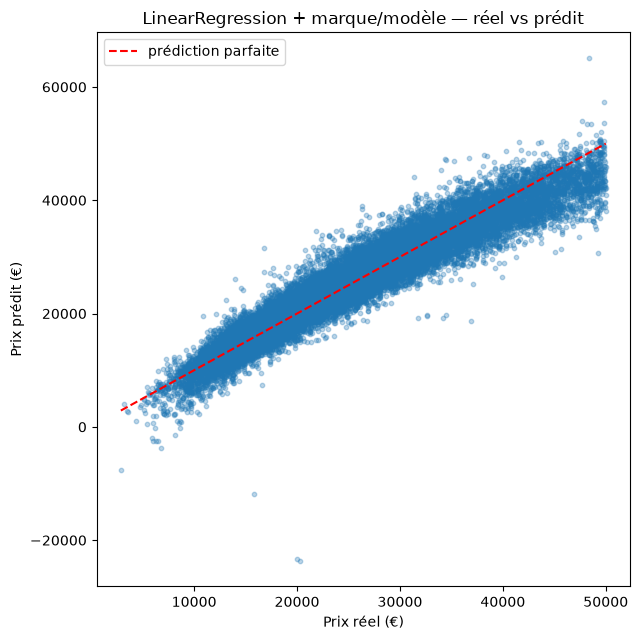

In [5]:
def evalue(m, tag=""):
    yp = m.predict(X_test)
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2   = r2_score(y_test, yp)
    print(f"{tag}MAE : {mae:,.0f} € | RMSE : {rmse:,.0f} € | R² : {r2:.3f}")
    return yp, mae, rmse, r2

y_pred, *_ = evalue(model)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
plt.title("LinearRegression + marque/modèle — réel vs prédit"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Hyperparamètre `fuel` : tuner `min_frequency` par validation croisée

On laisse `GridSearchCV` choisir le regroupement des carburants qui minimise la MAE.
`min_frequency` élevé → plus de carburants rares fusionnés dans `infrequent`.
`min_frequency=1` garde les 8 modalités brutes.

In [6]:
grid = GridSearchCV(
    Pipeline([("prep", build_prep()), ("lin", LinearRegression())]),
    param_grid={"prep__fuel__min_frequency": [1, 200, 500, 1000, 5000]},
    scoring="neg_mean_absolute_error",
    cv=3, n_jobs=-1,
)
grid.fit(X_train, y_train)

res = pd.DataFrame(grid.cv_results_)[["param_prep__fuel__min_frequency", "mean_test_score"]]
res["MAE_cv"] = -res["mean_test_score"]
print("MAE (validation croisée) par min_frequency :")
print(res[["param_prep__fuel__min_frequency", "MAE_cv"]].to_string(index=False))
print()
print("Meilleur min_frequency :", grid.best_params_["prep__fuel__min_frequency"])
evalue(grid.best_estimator_, tag="Meilleur modèle — ")

MAE (validation croisée) par min_frequency :
 param_prep__fuel__min_frequency      MAE_cv
                               1 2187.064702
                             200 2187.848919
                             500 2187.848919
                            1000 2194.245550
                            5000 2194.184568

Meilleur min_frequency : 1
Meilleur modèle — MAE : 2,155 € | RMSE : 2,837 € | R² : 0.913


(array([15986.05502218, 30225.41701867, 17199.69873915, ...,
        24043.31180137, 17669.11603366, 32398.74384204], shape=(24863,)),
 2155.194001667259,
 np.float64(2836.908180968284),
 0.9127074739546536)

## 6. Lecture des coefficients (top ± 15)

Coefficients sur variables standardisées / OneHot → effet en € sur le prix.

In [7]:
prep = model.named_steps["prep"]
names = (num_features
         + list(prep.named_transformers_["fuel"].get_feature_names_out(fuel_feature))
         + list(prep.named_transformers_["brand"].get_feature_names_out(brand_feature))
         + list(prep.named_transformers_["model"].get_feature_names_out(model_feature)))
coefs = pd.Series(model.named_steps["lin"].coef_, index=names).sort_values()
print("Intercept :", f"{model.named_steps['lin'].intercept_:,.0f} €\n")
print("--- 15 plus négatifs ---"); print(coefs.head(15).round(0))
print("\n--- 15 plus positifs ---"); print(coefs.tail(15).round(0))

Intercept : 32,892 €

--- 15 plus négatifs ---
model2_TRAX                      -25195.0
model2_AVEO 2                    -22370.0
model2_SPARK                     -21632.0
model2_C-ZERO                    -17170.0
model2_SPACE STAR 2              -16516.0
model2_ION                       -15416.0
model2_JAZZ 4                    -14109.0
model2_ROVER FREELANDER 2        -13337.0
model2_AYGO 2                    -13164.0
model2_S80 (2E GENERATION)       -12975.0
model2_ROVER RANGE ROVER SPORT   -12967.0
model2_E-MEHARI                  -12187.0
model2_CLASSE C 2                -12186.0
model2_CAMARO 5 CABRIOLET        -11939.0
model2_FIESTA 6                  -11496.0
dtype: float64

--- 15 plus positifs ---
model2_XJS COUPE                26318.0
model2_968                      26641.0
model2_SERIE 3 E36 COUPE M3     30242.0
model2_PARK LANE CABRIOLET      30574.0
model1_MERCURY                  30574.0
model2_MASTER 2                 33161.0
model1_AUSTIN                   36371.0
mo

## 7. `model2` en target encoding (vs OneHot 991 colonnes)

Au lieu de ~920 colonnes 0/1, **une seule** colonne : chaque modèle remplacé par une valeur
apprise de la cible (prix moyen du modèle, calibré). `sklearn.TargetEncoder` fait un
**cross-fitting interne** → pas de fuite. `model1` et `fuel` restent en OneHot.

In [8]:
from sklearn.preprocessing import TargetEncoder

prep_te = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ]), num_features),
    ("fuel",  OneHotEncoder(handle_unknown="ignore", sparse_output=False), fuel_feature),
    ("brand", OneHotEncoder(handle_unknown="ignore", sparse_output=False), brand_feature),
    ("model", TargetEncoder(target_type="continuous"), model_feature),
])

model_te = Pipeline([("prep", prep_te), ("lin", LinearRegression())])
model_te.fit(X_train, y_train)
n_te = model_te.named_steps["prep"].transform(X_train.head(1)).shape[1]
print("colonnes après préprocessing :", n_te, "(vs 991 en OneHot)")
evalue(model_te, tag="TargetEncoder model2 — ")

colonnes après préprocessing : 68 (vs 991 en OneHot)
TargetEncoder model2 — MAE : 2,632 € | RMSE : 3,457 € | R² : 0.870


(array([17736.2311028 , 29950.21798541, 19753.6191084 , ...,
        24407.37566512, 17098.9688173 , 29617.80876825], shape=(24863,)),
 2631.6520698985164,
 np.float64(3457.325828362661),
 0.8703516114773817)

### Comparaison OneHot vs TargetEncoder sur `model2`

Pour juger le **surapprentissage** : écart train ↔ test. Un modèle qui triche mémorise
le train (erreur train ≪ erreur test).

In [9]:
def train_test_mae(m, tag):
    mae_tr = mean_absolute_error(y_train, m.predict(X_train))
    mae_te = mean_absolute_error(y_test,  m.predict(X_test))
    print(f"{tag:28s} | MAE train {mae_tr:6,.0f} € | MAE test {mae_te:6,.0f} € | écart {mae_te-mae_tr:5,.0f} €")

print("model2 encodé en :")
train_test_mae(model,    "OneHot (991 col)")
train_test_mae(model_te, "TargetEncoder (1 col)")

model2 encodé en :
OneHot (991 col)             | MAE train  2,154 € | MAE test  2,155 € | écart     1 €


TargetEncoder (1 col)        | MAE train  2,632 € | MAE test  2,632 € | écart    -0 €
